In [ ]:
#!pip install fiftyone

In [ ]:
#!pip install segmentation_models_pytorch

In [1]:
import os
from google.colab import drive

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import fiftyone as fo
import fiftyone.zoo as foz
import segmentation_models_pytorch as smp

from glob import glob
from matplotlib import pyplot as plt

from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
fo.config.dataset_zoo_dir = "/content/drive/MyDrive/dataset_v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
device

device(type='cuda')

In [ ]:
# dataset = fo.zoo.load_zoo_dataset(
#     "open-images-v7",
#     split="train",
#     label_types=["segmentations"],
#     dataset_dir="/content/drive/MyDrive/dataset/open-images-v7",
#     max_samples=750,
# )

In [ ]:
dataset.compute_metadata()

In [ ]:
sample = dataset.first()
print(sample.metadata.height, sample.metadata.width)

768 1024


In [ ]:
output_mask_dir = "G:/datasets/open-images-v7/train/labels/masks"

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        image = image.resize(self.size, Image.BILINEAR)
        mask = mask.resize(self.size, Image.NEAREST)

        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.int64)

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask)

        return image, mask

In [6]:
# UNet model structure created manually
class UNet(nn.Module):
    def __init__(self, num_classes):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [7]:
# Training loop
def train_segmentation_model(
    model,
    dataset,
    device,
    num_epochs=10,
    batch_size=4,
    learning_rate=1e-4,
    num_classes=4,
    weights=None
):
    val_split = 0.1
    val_size = int(val_split * len(dataset))
    train_size = len(dataset) - val_size
    train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, num_workers=2)
    model = model.to(device)
    weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
    dice_loss = smp.losses.DiceLoss(mode="multiclass")
    ce_loss = nn.CrossEntropyLoss(weight = weights_tensor)

    y_true = []
    y_pred = []

    model.eval()
    val_loss = 0.0

    def combined_loss(pred, target):
        return dice_loss(pred, target) + ce_loss(pred, target)

    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)

            if isinstance(outputs, dict):
                outputs = outputs["out"]

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]

                loss = criterion(outputs, masks)
                val_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)
                max_probs, preds = torch.max(probs, dim=1)

                preds[max_probs < 0.6] = 0

                y_true.extend(masks.cpu().numpy().flatten())
                y_pred.extend(preds.cpu().numpy().flatten())

        avg_val_loss = val_loss / len(val_loader)

        # accuracy = accuracy_score(y_true, y_pred)
        # precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
        # recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
        # f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {avg_loss:.4f}  Val Loss: {avg_val_loss:.4f}")
        # print("✅ Evaluation Metrics:")
        # print(f"Accuracy: {accuracy}")
        # print(f"Precision: {precision}")
        # print(f"Recall: {recall}")
        # print(f"F1 Score: {f1}")

    return model


In [8]:
# Get model statistsics
def evaluate_model(model, dataloader, device):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            if isinstance(outputs, dict):
                outputs = outputs["out"]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(masks.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())

    print("✅ Evaluation Metrics:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average="macro", zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average="macro", zero_division=0))

In [9]:
# Input an image path - predict the mask - return comparison
def predict_and_visualize(image_path, model, device, size=(256, 256), class_colors=None):
    original = Image.open(image_path).convert("RGB")
    resized = original.resize(size)
    image_np = np.array(resized).astype(np.float32) / 255.0
    image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape: (1, 3, H, W)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]

        prediction = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    prediction_resized = Image.fromarray(prediction.astype(np.uint8)).resize(original.size, Image.NEAREST)
    prediction_resized = np.array(prediction_resized)

    if class_colors:
        color_mask = np.zeros((*prediction_resized.shape, 3), dtype=np.uint8)
        for class_id, color in class_colors.items():
            color_mask[prediction_resized == class_id] = color
    else:
        color_mask = prediction_resized

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(color_mask if class_colors else prediction_resized, cmap="tab10")
    plt.title("Predicted Mask")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [10]:
# Since classes are so imbalanced, calculation of class weights is needed
def compute_class_weights(mask_paths, num_classes):
    class_counts = np.zeros(num_classes)

    for mask_path in tqdm(mask_paths):
        mask = np.array(Image.open(mask_path))
        for c in range(num_classes):
            class_counts[c] += np.sum(mask == c)

    class_counts[class_counts == 0] = 1

    weights = 1.0 / class_counts
    weights = weights / weights.sum()  # Normalize to sum to 1
    return weights

OpenImages extracts images that contain the masks for all chosen classes. The problem with this is that it downloads ALL masks for those images - including classes that are not needed in my case. In this code we take only needed masks and process them for training.

In [ ]:
output_mask_dir = "/content/drive/MyDrive/dataset/open-images-v7/train/labels/masks"
os.makedirs(output_mask_dir, exist_ok=True)

image_paths = []
mask_paths = []

label_map = {
    "Car": 1,
    "Motorcycle": 2,
    "Bus": 3,
}

for sample in dataset:
    detections = sample["ground_truth"].detections
    height = sample.metadata.height
    width = sample.metadata.width

    mask = np.zeros((height, width), dtype=np.uint8)

    for det in detections:
        class_id = label_map.get(det.label)
        if class_id is None:
            continue  # skip classes that we don't need

        class_id = label_map.get(det.label)
        if class_id is None:
            continue  # skip unknown classes

        binary_mask = det.mask.astype(np.uint8)

        x, y, w, h = det.bounding_box
        x1 = int(x * width)
        y1 = int(y * height)
        x2 = int((x + w) * width)
        y2 = int((y + h) * height)

        if x2 <= x1 or y2 <= y1:
            continue

        resized = Image.fromarray(binary_mask * 255).resize(
            (x2 - x1, y2 - y1), resample=Image.NEAREST
        )
        resized_mask = np.array(resized) > 0

        mask[y1:y2, x1:x2][resized_mask] = class_id

    if np.any(mask):
        mask_path = os.path.join(output_mask_dir, f"{sample.id}.png")
        Image.fromarray(mask).save(mask_path)

        image_paths.append(sample.filepath)
        mask_paths.append(mask_path)

NameError: name 'dataset' is not defined

When we have all our images and their respective masks - we can gather all the paths and we will later use these paths for all other functions

In [11]:
image_paths_train = sorted(glob("/content/drive/MyDrive/dataset/open-images-v7/train/data/*.jpg"))
mask_paths_train = sorted(glob("/content/drive/MyDrive/dataset/open-images-v7/train/labels/masks/*.png"))

In [12]:
image_paths_test = sorted(glob("/content/drive/MyDrive/dataset/open-images-v7/test/data/*.jpg"))
mask_paths_test = sorted(glob("/content/drive/MyDrive/dataset/open-images-v7/test/labels/masks/*.png"))

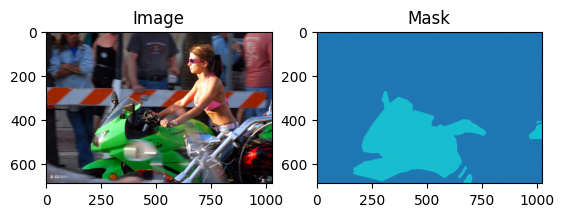

In [23]:
img = np.array(Image.open(image_paths_test[3]))
mask = np.array(Image.open(mask_paths_test[3]))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab10")
plt.title("Mask")

plt.show()

We crate datasets and DataLoaders for training set and testing set.
The Training set contains 750 images. Testing contains 100 new Images.

In [13]:
dataset_train = SegmentationDataset(image_paths_train, mask_paths_train, size = (256, 256))

In [14]:
dataset_test = SegmentationDataset(image_paths_test, mask_paths_test, size = (256, 256))

In [15]:
train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=8, shuffle=True)

In [16]:
model = UNet(num_classes=4).to(device)

We compute the class weights.

This is something I noticed is needed, because without Dice Loss and Weights we get a model that always predicts the dominant class (car). Since Motorcycle and Bus images are much more rare in our dataset, the model just always predicts car as it learned that guessing car almost almost is correct.

Adding weights and Dice Loss in our training loop helps fix this.

In [17]:
weights = compute_class_weights(mask_paths_train, num_classes=4)
print("Class weights:", weights)

100%|██████████| 750/750 [00:07<00:00, 105.12it/s]

Class weights: [0.01986924 0.08635725 0.53425264 0.35952087]


In [ ]:
# Import an already trained model (.pth file)
# model = UNet(num_classes=4).to(device)
# model.load_state_dict(torch.load("/content/drive/MyDrive/dataset/unet_model.pth", map_location=torch.device('cpu')))
# model.to(device)
# model.eval()

This is the main training loop.
num_classes is 4 and not 3, because we are also predicting the 'background'

In [20]:
model = train_segmentation_model(
    model=model,
    dataset=dataset_train,
    device=device,
    num_epochs=5,
    batch_size=8,
    learning_rate=1e-4,
    num_classes=4,
    weights = weights
)

Epoch [1/5]
Train Loss: 1.4385  Val Loss: 1.4917
Epoch [2/5]
Train Loss: 1.3581  Val Loss: 1.6732
Epoch [3/5]
Train Loss: 1.3481  Val Loss: 1.4677
Epoch [4/5]
Train Loss: 1.2897  Val Loss: 1.4420
Epoch [5/5]
Train Loss: 1.3030  Val Loss: 1.4311


In [ ]:
# torch.save(model.state_dict(), "/content/drive/MyDrive/dataset/unet_model_smp.pth")

Calling `evaluate_model()` to get the Accuracy, Precision, Recall, F1 Score.

The overall accuracy can be quite misleading, because a model could be good at predicting the background really well.

In [21]:
evaluate_model(model, test_loader, device)

✅ Evaluation Metrics:
Accuracy: 0.6601284790039063
Precision: 0.48997730389909855
Recall: 0.6529899874722108
F1 Score: 0.5270296709014071


In [22]:
class_colors = {
    0: (0, 0, 0),         # background = black
    1: (255, 0, 0),       # car = red
    2: (0, 255, 0),       # motorcycle = green
    3: (0, 0, 255),       # bus = blue
}

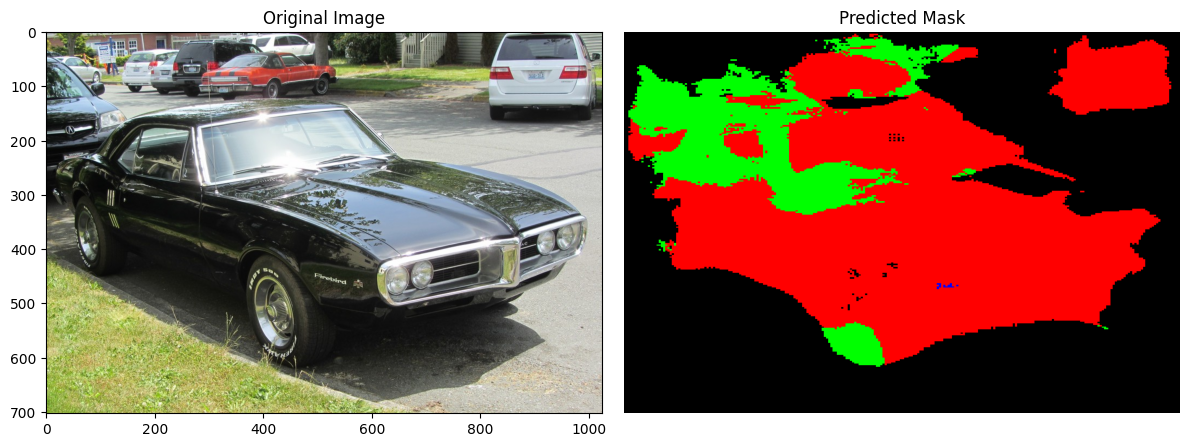

In [135]:
prediction = predict_and_visualize(image_paths_test[5], model, device, class_colors=class_colors)

We can also try using an already pre-built UNet structure. segmentation_models_pytorch has an UNet model with a pre-built encoder. This means that the model will most likely be much better at predicting the shapes and the edges of images. We can expect much better results.

In [109]:
import segmentation_models_pytorch as smp

In [110]:
model_smp = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)
model_smp = model_smp.to(device)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 194MB/s]


In [111]:
model_smp = train_segmentation_model(
    model=model_smp,
    dataset=dataset_train,
    device=device,
    num_epochs=15,
    batch_size=8,
    learning_rate=1e-4,
    num_classes=4,
    weights = weights
)

Epoch [1/15]
Train Loss: 1.6324  Val Loss: 1.2276
Epoch [2/15]
Train Loss: 1.1844  Val Loss: 1.1145
Epoch [3/15]
Train Loss: 0.9990  Val Loss: 0.8861
Epoch [4/15]
Train Loss: 0.8489  Val Loss: 0.8308
Epoch [5/15]
Train Loss: 0.7425  Val Loss: 0.7580
Epoch [6/15]
Train Loss: 0.6296  Val Loss: 0.8906
Epoch [7/15]
Train Loss: 0.6291  Val Loss: 0.9197
Epoch [8/15]
Train Loss: 0.5812  Val Loss: 0.6219
Epoch [9/15]
Train Loss: 0.5898  Val Loss: 0.8376
Epoch [10/15]
Train Loss: 0.5159  Val Loss: 0.7124
Epoch [11/15]
Train Loss: 0.4157  Val Loss: 0.7298
Epoch [12/15]
Train Loss: 0.4623  Val Loss: 0.7801
Epoch [13/15]
Train Loss: 0.3937  Val Loss: 0.8566
Epoch [14/15]
Train Loss: 0.3539  Val Loss: 0.7712
Epoch [15/15]
Train Loss: 0.3925  Val Loss: 0.8895


In [112]:
evaluate_model(model_smp, test_loader, device)

✅ Evaluation Metrics:
Accuracy: 0.7680717468261719
Precision: 0.6618723723911951
Recall: 0.8033033863260488
F1 Score: 0.7030109153634989


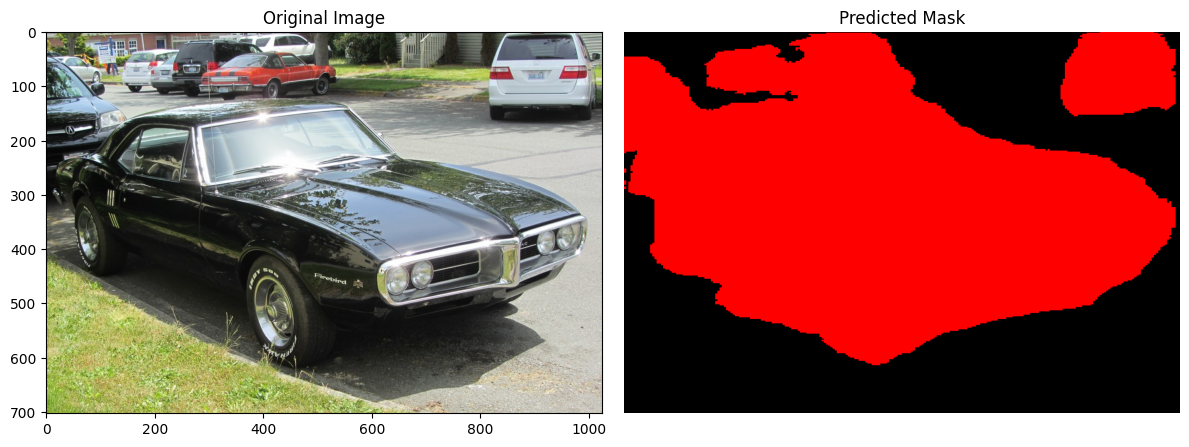

In [127]:
prediction = predict_and_visualize(image_paths_test[5], model_smp, device, class_colors=class_colors)

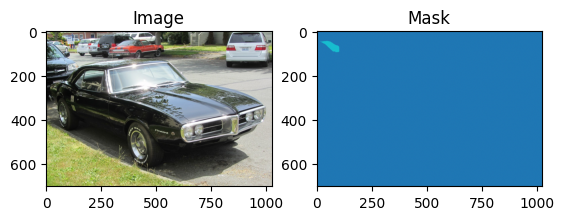

In [136]:
img = np.array(Image.open(image_paths_test[5]))
mask = np.array(Image.open(mask_paths_test[5]))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="tab10")
plt.title("Mask")

plt.show()

In [ ]:
#!pip install git+https://github.com/facebookresearch/segment-anything.git
#!pip install opencv-python matplotlib

In [ ]:
#!pip install -q segmentation-models-pytorch